# 1 Preamble

In [1]:
import numpy as np
import random

import seaborn as sns
import matplotlib as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors

In [2]:
cmap1 = plt.cm.RdBu(np.linspace(0, 0.5, 128))
cmap2 = plt.cm.PuOr(np.linspace(0.5, 1, 128))

mycmap = mcolors.LinearSegmentedColormap.from_list('my_colormap', np.vstack((cmap1, cmap2)))

In [ ]:
TYPE_STATE = range(15)
ACTIONS = ['up', 'down', 'left', 'right']
ACTIONSYMBOLS = {'up': "↑", 'down': "↓", 'left': "←", 'right': "→", '':''}

MAZEIMAGE = mpimg.imread('MouseMaze2.png') 
CHEESEPOSITION = [(0,4)]

# 2 Environment

In [4]:
Maze = np.array([
    [0,13,2,12,11,2,11,2,0,2],
    [14,11,8,6,2,6,13,5,9,14],
    [6,13,11,1,5,0,13,8,0,8],
    [12,0,8,14,9,6,13,13,5,12],
    [6,8,0,7,2,11,13,2,6,5],
    [0,2,6,2,6,2,0,8,12,14],
    [14,6,13,8,12,6,8,0,7,8],
    [6,2,0,13,8,11,2,6,13,2],
    [0,8,3,10,0,2,3,1,10,14],
    [6,13,7,13,8,6,8,6,13,8]
])

![MouseMaze.png](MouseMaze.png)

# 3 Dynamic environment

We determine the next state and reward given the current state and action.

In [5]:
def NextStateAndReward(Position, Action, Rewards={'tired':0, 'cheese':1}, Environment=Maze):

    # General behavior of the actions
    if Action == 'up':
        NextPosition = (Position[0]-1, Position[1])
    elif Action == 'down':
        NextPosition = (Position[0]+1, Position[1])
    elif Action == 'left':
        NextPosition = (Position[0], Position[1]-1)
    else:
        NextPosition = (Position[0], Position[1]+1)

    # Special behavior for each state
    if Environment[Position] == 0:
        if Action in ['up', 'left']:
            NextPosition = Position
    elif Environment[Position] == 1:
        if Action in ['up']:
            NextPosition = Position
    elif Environment[Position] == 2:
        if Action in ['up', 'right']:
            NextPosition = Position
    elif Environment[Position] == 3:
        if Action in ['left']:
            NextPosition = Position
    elif Environment[Position] == 5:
        if Action in ['right']:
            NextPosition = Position
    elif Environment[Position] == 6:
        if Action in ['left', 'down']:
            NextPosition = Position
    elif Environment[Position] == 7:
        if Action in ['down']:
            NextPosition = Position
    elif Environment[Position] == 8:
        if Action in ['right', 'down']:
            NextPosition = Position
    elif Environment[Position] == 9:
        if Action in ['right', 'left', 'down']:
            NextPosition = Position
    elif Environment[Position] == 10:
        if Action in ['right', 'up', 'down']:
            NextPosition = Position
    elif Environment[Position] == 11:
        if Action in ['up', 'left', 'down']:
            NextPosition = Position
    elif Environment[Position] == 12:
        if Action in ['right', 'left', 'up']:
            NextPosition = Position
    elif Environment[Position] == 13:
        if Action in ['up', 'down']:
            NextPosition = Position
    elif Environment[Position] == 14:
        if Action in ['right', 'left']:
            NextPosition = Position

    if NextPosition in CHEESEPOSITION:
        Reward = Rewards['cheese']
    else:
        Reward = Rewards['tired']

    return (NextPosition, Reward)

# 4 Iterative state-action value evaluation

In [6]:
def PlotPolicyValue(Policy, Value, DeterministicPolicy=True):
    if DeterministicPolicy:
        Aux = sns.heatmap(
        Value,
        annot=np.vectorize(ACTIONSYMBOLS.get)(Policy),
        fmt = '',
        cmap=mycmap,
        vmin=-1,
        vmax=1,
        #linewidths=0.7,
        #linecolor="black",
        xticklabels=[],
        yticklabels=[],
        square=True,
        cbar=False
        )
        
        Aux.imshow(MAZEIMAGE,
          aspect = Aux.get_aspect(),
          extent = Aux.get_xlim() + Aux.get_ylim(),
          zorder = 1) #put the map under the heatmap
    else:
        Aux = sns.heatmap(
        Value,
        cmap=mycmap,
        vmin=-1,
        vmax=1,
        #linewidths=0.7,
        #linecolor="black",
        xticklabels=[],
        yticklabels=[],
        square=True,
        cbar=False
        )

        Aux.imshow(MAZEIMAGE,
          aspect = Aux.get_aspect(),
          extent = Aux.get_xlim() + Aux.get_ylim(),
          zorder = 1) #put the map under the heatmap

In [7]:
def ConvertStateActionToPositionTable(s, a, Environment=Maze):
    Worldsize = Environment.shape
    return (s[0]*Worldsize[1] + s[1], ACTIONS.index(a))

In [8]:
def PolicyActionEvaluation(
        Policy,
        Environment=Maze,
        Rewards={'tired':0, 'cheese':1},
        DiscountRate=0.97,
        NumberIterations=100,
        DeterministicPolicy=True,
        Slippery=False,
        SlipperyDistribution=None,
        Story=False
    ):
    # If Slippery is True, we have to give the SlipperyDistribution also

    Worldsize = Environment.shape

    QTable = np.zeros((Worldsize[0]*Worldsize[1], len(ACTIONS)))

    for _ in range(NumberIterations):
        NewQTable = np.zeros((Worldsize[0]*Worldsize[1], len(ACTIONS)))
        for i in range(Worldsize[0]):
            for j in range(Worldsize[1]):
                if (i,j) not in CHEESEPOSITION:
                    if DeterministicPolicy:
                        # Deterministic Policy
                        if not Slippery:
                            # Deterministic Environment
                            Action = Policy((i,j))
                            NextPosition, Reward = NextStateAndReward((i,j), Action, Rewards, Environment)

                            Aux = 0
                            if NextPosition not in CHEESEPOSITION:
                                ActionPrime = Policy(NextPosition)
                                Aux += QTable[ConvertStateActionToPositionTable(NextPosition, ActionPrime, Environment)]

                            NewQTable[ConvertStateActionToPositionTable((i,j), Action, Environment)] += Reward + DiscountRate * Aux
                        else:
                            # Stochastic Environment
                            Action = Policy((i,j))
                            # We have to take into account the distribution of possible actions
                            for ActualAction in SlipperyDistribution[Action]:
                                ProbActualAction = SlipperyDistribution[Action][ActualAction]
                                NextPosition, Reward = NextStateAndReward((i,j), ActualAction, Rewards, Environment)

                                Aux = 0
                                if NextPosition not in CHEESEPOSITION:
                                    ActionPrime = Policy(NextPosition)
                                    Aux += QTable[ConvertStateActionToPositionTable(NextPosition, ActionPrime, Environment)]

                                NewQTable[ConvertStateActionToPositionTable((i,j), Action, Environment)] += ProbActualAction * (Reward + DiscountRate * Aux)
                    else:
                        # Stochastic Policy
                        if not Slippery:
                            # Deterministic Environment
                            for Action in Policy((i,j), Environment):
                                NextPosition, Reward = NextStateAndReward((i,j), Action, Rewards, Environment)

                                Aux = 0
                                if NextPosition not in CHEESEPOSITION:
                                    for ActionPrime in Policy(NextPosition, Environment):
                                        ProbActionPrime = Policy(NextPosition, Environment)[ActionPrime]
                                        Aux += ProbActionPrime * QTable[ConvertStateActionToPositionTable(NextPosition, ActionPrime, Environment)]

                                NewQTable[ConvertStateActionToPositionTable((i,j), Action, Environment)] += Reward + DiscountRate * Aux
                        else:
                            # Stochastic Environment
                            for Action in Policy((i,j), Environment):
                                # We have to take into account the distribution of possible actions
                                for ActualAction in SlipperyDistribution[Action]:
                                    ProbActualAction = SlipperyDistribution[Action][ActualAction]
                                    NextPosition, Reward = NextStateAndReward((i,j), ActualAction, Rewards, Environment)

                                    Aux = 0
                                    if NextPosition not in CHEESEPOSITION:
                                        for ActionPrime in Policy(NextPosition, Environment):
                                            ProbActionPrime = Policy(NextPosition, Environment)[ActionPrime]
                                            Aux += ProbActionPrime * QTable[ConvertStateActionToPositionTable(NextPosition, ActionPrime, Environment)]
                                    
                                    NewQTable[ConvertStateActionToPositionTable((i,j), Action, Environment)] += ProbActualAction * (Reward + DiscountRate * Aux)
                    
                else:
                    pass

        QTable = np.copy(NewQTable)

        if Story:
            print(QTable.round(2))
            print(  )

    return(QTable)

# 5 Iterative policy improvement

In [9]:
def GreedyPolicy(QTable, Environment=Maze):
    Worldsize = Environment.shape

    Policy = []

    for s in range(len(QTable)):
        if np.all(np.isclose(QTable[s], QTable[s][0])):
            Policy.append(random.choice(ACTIONS))
        else:
            Policy.append(ACTIONS[np.argmax(QTable[s])])

    Policy = np.array(Policy).reshape((Worldsize[0],Worldsize[1]))

    for i in range(Worldsize[0]):
        for j in range(Worldsize[1]):
            if (i,j) in CHEESEPOSITION:
                Policy[i,j] = ''

    return Policy

In [10]:
def ValueFromQTable(QTable, Policy, Environment=Maze, DeterministicPolicy=True):
    Worldsize = Environment.shape

    StateValue = np.zeros(Worldsize)
    
    for i in range(Worldsize[0]):
        for j in range(Worldsize[1]):
            if (i,j) not in CHEESEPOSITION:
                if DeterministicPolicy:
                    # Deterministic Policy
                    Action = Policy((i,j))
                    StateValue[i,j] = QTable[ConvertStateActionToPositionTable((i,j), Action, Environment)]
                else:
                    # Stochastic Policy
                    for Action in Policy((i,j), Environment):
                        ProbAction = Policy((i,j), Environment)[Action]
                        StateValue[i,j] += ProbAction * QTable[ConvertStateActionToPositionTable((i,j), Action, Environment)]

    return StateValue

In [11]:
def PolicyIterativeEstimation(
        Policy,
        Environment=Maze,
        Rewards={'tired':0, 'cheese':1},
        DiscountRate=0.97,
        NumberIterations=100,
        DeterministicPolicy=True,
        Slippery=False,
        SlipperyDistribution=None,
        Story=False
    ):
    for _ in range(NumberIterations):
        # Policy Evaluation
        QTable = PolicyActionEvaluation(
            Policy,
            Environment,
            Rewards,
            DiscountRate,
            NumberIterations,
            DeterministicPolicy,
            Slippery,
            SlipperyDistribution,
            Story
        )

        ValuePolicy = ValueFromQTable(
            QTable,
            Policy,
            Environment,
            DeterministicPolicy
        )

        # Policy Improvement
        PolicyArray = GreedyPolicy(QTable, Environment)
        if not DeterministicPolicy:
            DeterministicPolicy = True

        def Policy(Position):
            return PolicyArray[Position]

        if Story:
            print("QTable:\n")
            print(QTable.round(2))
            print(  )

            print("State Value:\n")
            print(ValuePolicy.round(2))
            print(  )

            print("k:{}\n".format(_+1))
            print("Policy:\n")
            print(np.vectorize(ACTIONSYMBOLS.get)(PolicyArray))
            print(  )

    return PolicyArray, ValuePolicy

---

# 1 Policy

In [12]:
def Policy4(Position, Environment=Maze):
    Distribution = {'up':0.25, 'down':0.25, 'left':0.25, 'right':0.25}

    if Position not in CHEESEPOSITION:
        return Distribution
    else:
        return None

# 2 State-action value function evaluation

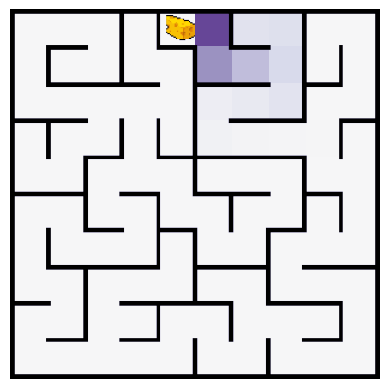

In [13]:
QTablePolicy4 = PolicyActionEvaluation(Policy=Policy4, DeterministicPolicy=False)
ValuePolicy4 = ValueFromQTable(QTablePolicy4, Policy4, DeterministicPolicy=False)
PlotPolicyValue(Policy4, ValuePolicy4, DeterministicPolicy=False)

# 3 Iterative policy improvement

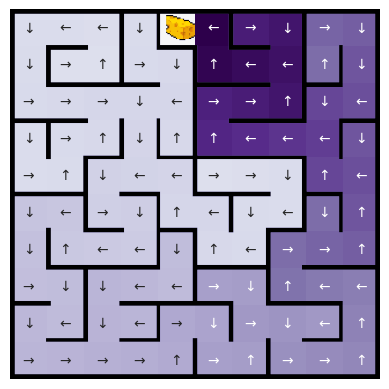

In [14]:
PolicyStar, ValueStar = PolicyIterativeEstimation(Policy4, DeterministicPolicy=False)
PlotPolicyValue(PolicyStar, ValueStar)